# Heart Disease Risk Predictor
# Baseline Machine Learning Models

## Objective
This notebook develops and compares several baseline machine learning classification models for predicting heart disease risk.

The objectives are:
- Train multiple baseline models
- Evaluate each model using the same evaluation metrics
- Compare model performance
- Identify the best-performing baseline model
The selected model will be optimized in the next notebook using hyperparameter tuning.

In [79]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

In [80]:
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT/"data"/"processed"
MODEL_DIR = PROJECT_ROOT/"models"
RESULT_DIR = PROJECT_ROOT/"results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_IMAGE_DIR = PROJECT_ROOT/"images"/"modeling"
MODEL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)
DPI = 300
FIGSIZE = (7,5)

In [81]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        MODEL_IMAGE_DIR/f"{filename}.png",
        dpi=DPI,
        bbox_inches="tight"
    )

    print(f"Saved : {filename}.png")

# Load Processed Dataset
The datasets generated during the feature engineering stage are loaded for model development.
Both standardized and non-standardized datasets are available because different algorithms have different preprocessing requirements.

In [82]:
X_train = pd.read_csv(PROCESSED_DIR/"X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR/"X_test.csv")
X_train_scaled = pd.read_csv(PROCESSED_DIR/"X_train_scaled.csv")
X_test_scaled = pd.read_csv(PROCESSED_DIR/"X_test_scaled.csv")
y_train = pd.read_csv(PROCESSED_DIR/"y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR/"y_test.csv").squeeze()

In [83]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


In [84]:
display(X_train.head())
display(X_train_scaled.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.729485,0.68313,0.870169,-0.395692,0.458139,-0.411196,1.022996,0.708371,-0.696177,-0.445445,0.675060,-0.689715,1.179973
1,0.050166,0.68313,-1.184278,-0.054513,0.230598,-0.411196,-0.981579,0.222495,-0.696177,-0.891627,-0.958585,-0.689715,-0.878070
2,-0.061212,-1.46385,-1.184278,0.059213,0.723605,2.431930,1.022996,0.399178,1.436416,-0.891627,-0.958585,0.445734,-0.878070
3,-0.061212,0.68313,-1.184278,-1.305501,1.121803,-0.411196,-0.981579,0.266666,-0.696177,-0.891627,-0.958585,-0.689715,1.179973
4,0.272924,-1.46385,0.870169,0.514117,-0.167601,-0.411196,-0.981579,-1.190962,1.436416,-0.713154,0.675060,-0.689715,1.179973


# Baseline Machine Learning Models
Six commonly used classification algorithms are selected as baseline models.
Each model is trained using its recommended preprocessing strategy.

In [85]:
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    )
}

# Evaluation Function
A reusable evaluation function is created to ensure that every model is evaluated using the same metrics.
This approach guarantees fair comparison across all baseline models.

In [86]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:,1]
    results = {
        "Accuracy": accuracy_score(y_test, prediction),
        "Precision": precision_score(y_test, prediction),
        "Recall": recall_score(y_test, prediction),
        "F1-Score": f1_score(y_test, prediction),
        "ROC-AUC": roc_auc_score(y_test, probability)
    }

    return (model, prediction, probability, results)

In [87]:
results = []
trained_models = {}

# Train Baseline Models
Each baseline model is trained using its appropriate input dataset.
Algorithms that rely on distance-based optimization are trained using standardized features, while tree-based algorithms are trained using the original features.
The trained models are saved for future evaluation and comparison.

In [88]:
logistic_model, logistic_prediction, logistic_probability, logistic_result = evaluate_model(
    models["Logistic Regression"], X_train_scaled, X_test_scaled, y_train, y_test)

trained_models["Logistic Regression"] = logistic_model
results.append({"Model":"Logistic Regression", **logistic_result})
joblib.dump(logistic_model, MODEL_DIR/"logistic_regression.pkl")

['..\\models\\logistic_regression.pkl']

In [89]:
knn_model, knn_prediction, knn_probability, knn_result = evaluate_model(
    models["K-Nearest Neighbors"], X_train_scaled, X_test_scaled, y_train, y_test)

trained_models["K-Nearest Neighbors"] = knn_model
results.append({"Model":"K-Nearest Neighbors", **knn_result})
joblib.dump(knn_model, MODEL_DIR/"knn.pkl")

['..\\models\\knn.pkl']

In [90]:
svm_model, svm_prediction, svm_probability, svm_result = evaluate_model(
    models["Support Vector Machine"], X_train_scaled, X_test_scaled, y_train, y_test)

trained_models["Support Vector Machine"] = svm_model
results.append({"Model":"Support Vector Machine", **svm_result})
joblib.dump(svm_model, MODEL_DIR/"svm.pkl")

['..\\models\\svm.pkl']

In [91]:
dt_model, dt_prediction, dt_probability, dt_result = evaluate_model(
    models["Decision Tree"], X_train, X_test, y_train, y_test)

trained_models["Decision Tree"] = dt_model
results.append({"Model":"Decision Tree", **dt_result})
joblib.dump(dt_model, MODEL_DIR/"decision_tree.pkl")

['..\\models\\decision_tree.pkl']

In [92]:
rf_model, rf_prediction, rf_probability, rf_result = evaluate_model(
    models["Random Forest"], X_train, X_test, y_train, y_test)

trained_models["Random Forest"] = rf_model
results.append({"Model":"Random Forest", **rf_result})
joblib.dump(rf_model, MODEL_DIR/"random_forest.pkl")

['..\\models\\random_forest.pkl']

In [93]:
xgb_model, xgb_prediction, xgb_probability, xgb_result = evaluate_model(
    models["XGBoost"], X_train, X_test, y_train, y_test)

trained_models["XGBoost"] = xgb_model
results.append({"Model":"XGBoost", **xgb_result})
joblib.dump(xgb_model, MODEL_DIR/"xgboost.pkl")

['..\\models\\xgboost.pkl']

# Model Verification
All trained baseline models are saved to the project directory.
These models will be reused during model comparison, hyperparameter tuning, and explainability analysis.

In [94]:
sorted([file.name for file in MODEL_DIR.iterdir()])

['best_baseline_model.pkl',
 'decision_tree.pkl',
 'knn.pkl',
 'logistic_regression.pkl',
 'random_forest.pkl',
 'standard_scaler.pkl',
 'svm.pkl',
 'xgboost.pkl']

In [95]:
print(f"Total trained models : {len(trained_models)}")

Total trained models : 6


# Model Comparison
The evaluation metrics of all baseline models are combined into a single DataFrame to facilitate performance comparison.

In [96]:
results_df = (pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True))
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723
3,K-Nearest Neighbors,0.885246,0.800000,1.000000,0.888889,0.923160
4,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
5,Decision Tree,0.737705,0.676471,0.821429,0.741935,0.744048


In [97]:
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9518
1,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
2,Support Vector Machine,0.8525,0.8065,0.8929,0.8475,0.9437
3,K-Nearest Neighbors,0.8852,0.8000,1.0000,0.8889,0.9232
4,XGBoost,0.8525,0.7879,0.9286,0.8525,0.9188
5,Decision Tree,0.7377,0.6765,0.8214,0.7419,0.7440


# Save Evaluation Results
The evaluation results are exported into multiple formats for reporting and future analysis.

In [98]:
results_df.to_csv(RESULT_DIR/"model_comparison.csv", index=False)

In [99]:
results_df.to_excel(RESULT_DIR/"model_comparison.xlsx", index=False)

In [100]:
results_df.to_json(RESULT_DIR/"metrics.json", orient="records", indent=4)

In [101]:
best_model = results_df.iloc[0]

In [102]:
summary = f"""
Heart Disease Risk Predictor
Baseline Modeling Summary

Total Models Evaluated: {len(results_df)}

Models:
{chr(10).join("- " + model for model in results_df["Model"])}

Best Baseline Model: {best_model["Model"]}
Accuracy  : {best_model["Accuracy"]:.4f}
Precision : {best_model["Precision"]:.4f}
Recall    : {best_model["Recall"]:.4f}
F1 Score  : {best_model["F1-Score"]:.4f}
ROC-AUC   : {best_model["ROC-AUC"]:.4f}

"""

In [103]:
with open(RESULT_DIR/"baseline_summary.txt", "w", encoding="utf-8") as file: file.write(summary)
print(summary)


Heart Disease Risk Predictor
Baseline Modeling Summary

Total Models Evaluated: 6

Models:
- Random Forest
- Logistic Regression
- Support Vector Machine
- K-Nearest Neighbors
- XGBoost
- Decision Tree

Best Baseline Model: Random Forest
Accuracy  : 0.8852
Precision : 0.8387
Recall    : 0.9286
F1 Score  : 0.8814
ROC-AUC   : 0.9518




# Save Classification Reports
Each trained model generates its own classification report.
The reports are saved individually for documentation purposes.

In [104]:
REPORT_DIR = RESULT_DIR/"classification_reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [105]:
prediction_dict = {
    "logistic_regression": logistic_prediction,
    "knn": knn_prediction,
    "svm": svm_prediction,
    "decision_tree": dt_prediction,
    "random_forest": rf_prediction,
    "xgboost": xgb_prediction
}

In [106]:
for model_name, prediction in prediction_dict.items():
    report = classification_report(y_test, prediction)
    with open(REPORT_DIR / f"{model_name}.txt", "w", encoding="utf-8") as file: file.write(report)

In [107]:
sorted([file.name for file in REPORT_DIR.iterdir()])

['decision_tree.txt',
 'knn.txt',
 'logistic_regression.txt',
 'random_forest.txt',
 'svm.txt',
 'xgboost.txt']

# Model Performance Visualization
The evaluation metrics are visualized to facilitate performance comparison across all baseline models.

Saved : accuracy_comparison.png


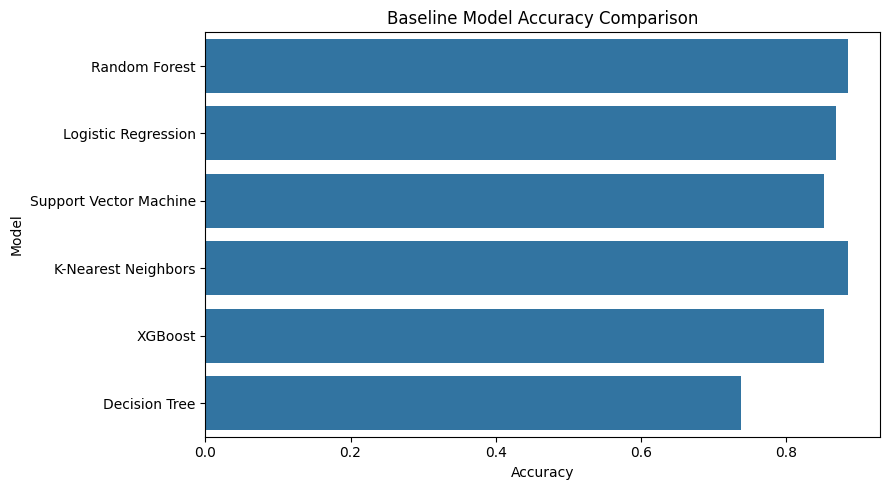

In [108]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Baseline Model Accuracy Comparison")
save_plot("accuracy_comparison")
plt.show()

Saved : precision_comparison.png


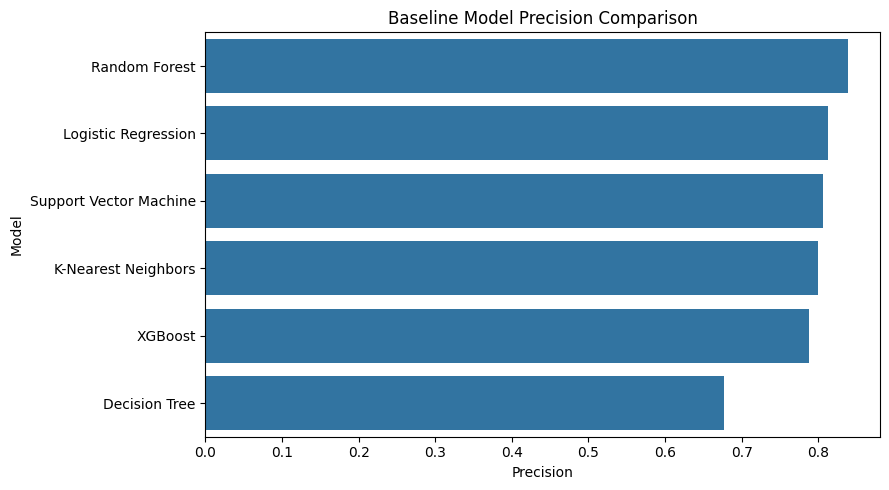

In [109]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Precision", y="Model")
plt.title("Baseline Model Precision Comparison")
save_plot("precision_comparison")
plt.show()

Saved : recall_comparison.png


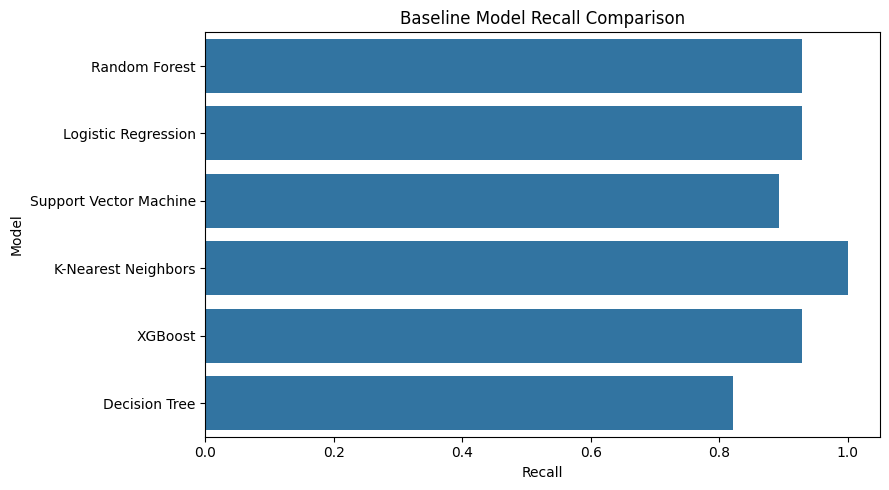

In [110]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Recall", y="Model")
plt.title("Baseline Model Recall Comparison")
save_plot("recall_comparison")
plt.show()

Saved : f1_comparison.png


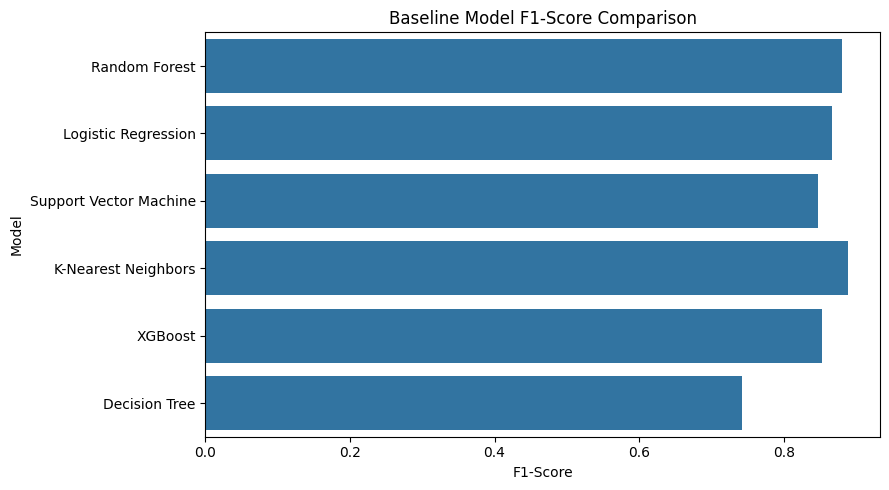

In [111]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="F1-Score", y="Model")
plt.title("Baseline Model F1-Score Comparison")
save_plot("f1_comparison")
plt.show()

Saved : roc_auc_comparison.png


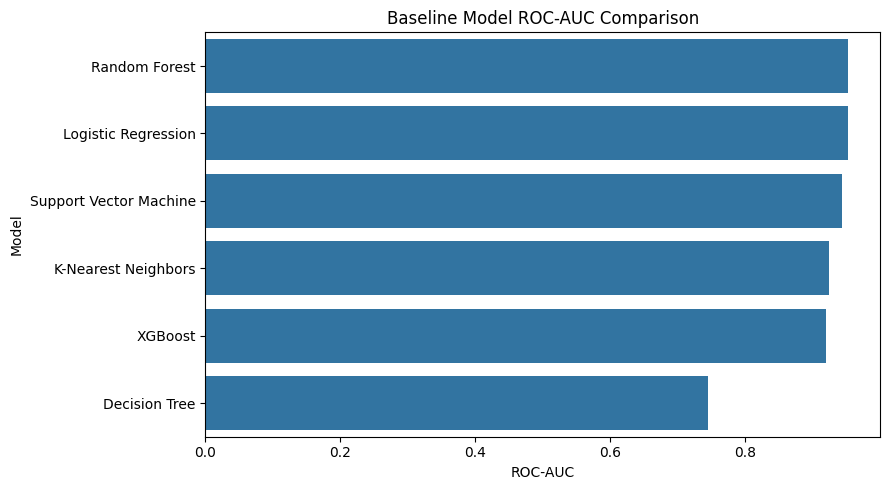

In [112]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model")
plt.title("Baseline Model ROC-AUC Comparison")
save_plot("roc_auc_comparison")
plt.show()

In [113]:
sorted([file.name for file in RESULT_DIR.iterdir()])

['baseline_summary.txt',
 'classification_reports',
 'feature_importance.csv',
 'metrics.json',
 'model_comparison.csv',
 'model_comparison.xlsx']

# ROC Curve Comparison
The Receiver Operating Characteristic (ROC) Curve compares the classification performance of all baseline models across different probability thresholds.
The Area Under the Curve (ROC-AUC) is used to evaluate each model's ability to distinguish between patients with and without heart disease.

Saved : roc_curve_all_models.png


<Figure size 800x600 with 0 Axes>

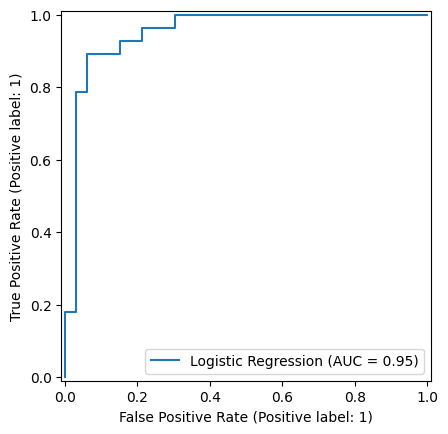

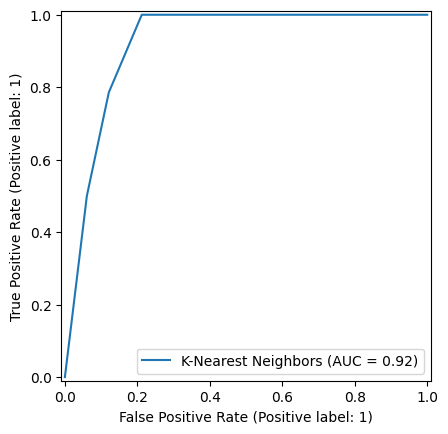

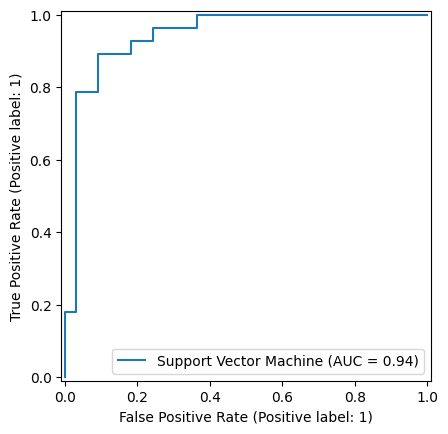

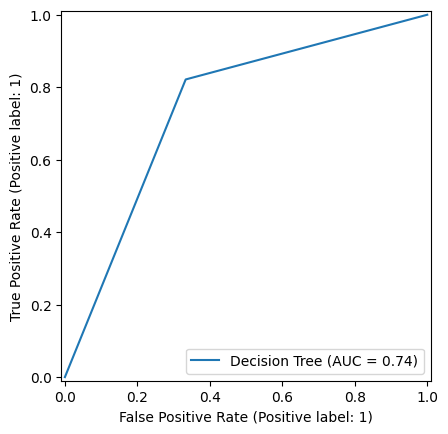

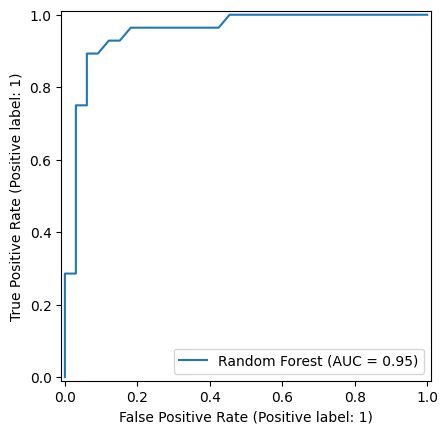

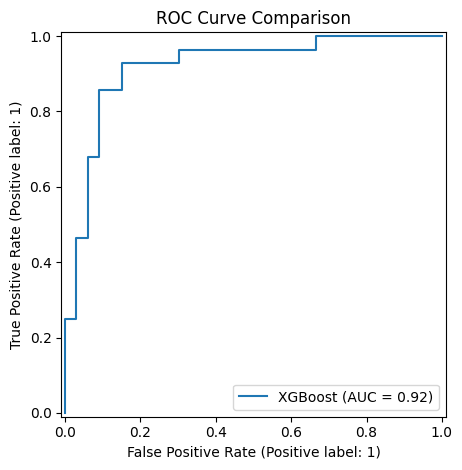

In [114]:
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, logistic_probability, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, knn_probability, name="K-Nearest Neighbors")
RocCurveDisplay.from_predictions(y_test, svm_probability, name="Support Vector Machine")
RocCurveDisplay.from_predictions(y_test, dt_probability, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, rf_probability, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, xgb_probability, name="XGBoost")
plt.title("ROC Curve Comparison")
save_plot("roc_curve_all_models")
plt.show()

# Best Baseline Model
The best-performing baseline model is selected based on the highest ROC-AUC score.
ROC-AUC is chosen because it evaluates the model across all possible classification thresholds and is less sensitive to class imbalance than accuracy alone.

In [115]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best Baseline Model : {best_model_name}")

Best Baseline Model : Random Forest


In [116]:
best_model_name

'Random Forest'

In [117]:
best_model_mapping = {
    "Logistic Regression": logistic_model,
    "K-Nearest Neighbors": knn_model,
    "Support Vector Machine": svm_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = best_model_mapping[best_model_name]

# Save Best Baseline Model
The best-performing baseline model is saved separately for the next stage of the project, where hyperparameter tuning will be performed.

In [118]:
joblib.dump(best_model, MODEL_DIR/"best_baseline_model.pkl")

['..\\models\\best_baseline_model.pkl']

# Confusion Matrix
The confusion matrix summarizes the prediction results of the selected baseline model.
It illustrates the number of correctly and incorrectly classified patients for each target class.

In [119]:
prediction_mapping = {
    "Logistic Regression": logistic_prediction,
    "K-Nearest Neighbors": knn_prediction,
    "Support Vector Machine": svm_prediction,
    "Decision Tree": dt_prediction,
    "Random Forest": rf_prediction,
    "XGBoost": xgb_prediction
}

best_prediction = prediction_mapping[best_model_name]

In [120]:
cm = confusion_matrix(y_test, best_prediction)

Saved : confusion_matrix_best_model.png


<Figure size 600x600 with 0 Axes>

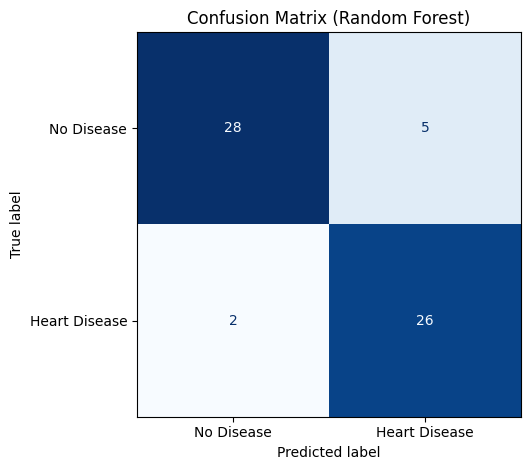

In [121]:
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=["No Disease", "Heart Disease"]).plot(cmap="Blues", colorbar=False)
plt.title(f"Confusion Matrix ({best_model_name})")
save_plot("confusion_matrix_best_model")
plt.show()

# Feature Importance
For tree-based models, feature importance provides an estimate of how much each predictor contributes to the model's decision-making process.
This analysis offers an initial interpretation before applying SHAP in the following notebooks.

In [122]:
if best_model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_}).sort_values(by="Importance", ascending=False)

    display(importance)

,Feature,Importance
7,thalach,0.135404
2,cp,0.127163
12,thal,0.122940
11,ca,0.100811
0,age,0.091327
9,oldpeak,0.089358
4,chol,0.088681
3,trestbps,0.080716
8,exang,0.050730
10,slope,0.046626


Saved : feature_importance.png


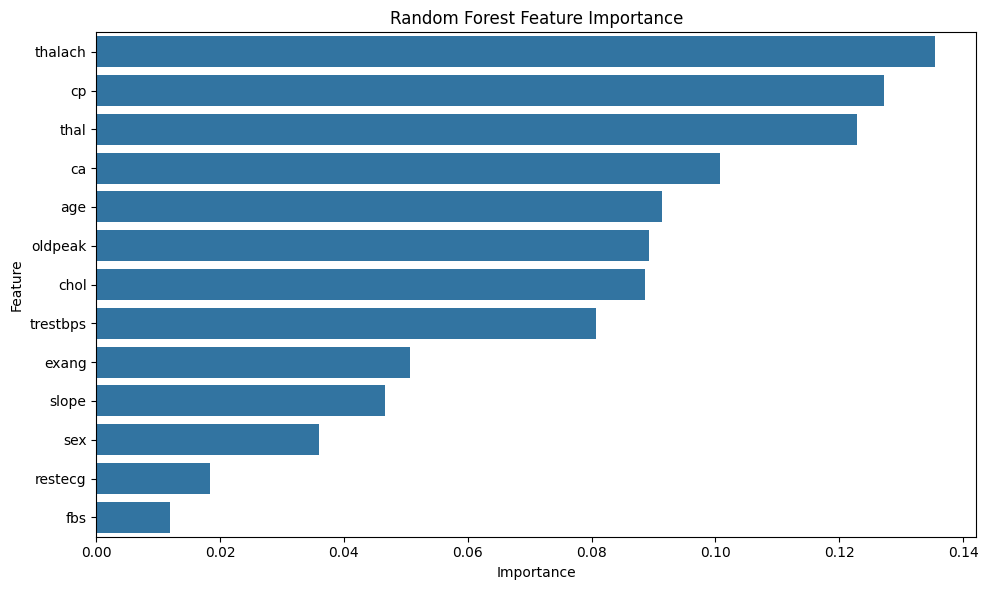

In [123]:
if best_model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
    plt.figure(figsize=(10,6))
    sns.barplot(data=importance, x="Importance", y="Feature")
    plt.title(f"{best_model_name} Feature Importance")
    save_plot("feature_importance")
    plt.show()

In [124]:
if best_model_name in ["Decision Tree", "Random Forest", "XGBoost"]:
    importance.to_csv(RESULT_DIR/"feature_importance.csv", index=False)

In [125]:
print("Saved Models")
display(sorted([file.name for file in MODEL_DIR.iterdir()]))
print()
print("Saved Results")
display(sorted([file.name for file in RESULT_DIR.iterdir()]))
print()
print("Saved Figures")
display(sorted([file.name for file in MODEL_IMAGE_DIR.iterdir()]))

Saved Models


['best_baseline_model.pkl',
 'decision_tree.pkl',
 'knn.pkl',
 'logistic_regression.pkl',
 'random_forest.pkl',
 'standard_scaler.pkl',
 'svm.pkl',
 'xgboost.pkl']


Saved Results


['baseline_summary.txt',
 'classification_reports',
 'feature_importance.csv',
 'metrics.json',
 'model_comparison.csv',
 'model_comparison.xlsx']


Saved Figures


['accuracy_comparison.png',
 'confusion_matrix_best_model.png',
 'f1_comparison.png',
 'feature_importance.png',
 'precision_comparison.png',
 'recall_comparison.png',
 'roc_auc_comparison.png',
 'roc_curve_all_models.png']

# Conclusion
Six baseline machine learning models were successfully trained and evaluated using a consistent evaluation framework.
The comparison identified the best-performing baseline model based on ROC-AUC and other classification metrics.
The selected model has been saved and will be optimized in the next notebook using hyperparameter tuning to further improve predictive performance.

# Next Step
The next notebook focuses on hyperparameter tuning.
The selected baseline model will be optimized using cross-validation and hyperparameter search techniques to obtain the best-performing predictive model before explainability analysis using SHAP.